In [1]:
!pip install tensorflow openpyxl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob, os

In [2]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping

In [3]:
data_folder   = r"/content"
output_folder = r"/content"

os.makedirs(output_folder, exist_ok=True)

files = glob.glob(os.path.join(data_folder, "RevenueCenter_*.xlsx"))

In [4]:
# Error matrix
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100

In [5]:
def create_sequences(series, window=30):
    X, y = [], []
    for i in range(len(series) - window):
        X.append(series[i:i+window])
        y.append(series[i+window])
    return np.array(X), np.array(y)


Processing: RevenueCenter_2
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 118ms/step - loss: 0.0168 - val_loss: 0.0239
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - loss: 0.0146 - val_loss: 0.0249
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - loss: 0.0177 - val_loss: 0.0278
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step - loss: 0.0127 - val_loss: 0.0203
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 116ms/step - loss: 0.0203 - val_loss: 0.0268
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - loss: 0.0167 - val_loss: 0.0260
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - loss: 0.0137 - val_loss: 0.0219
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - loss: 0.0189 - val_loss: 0.0268
Epoch 9/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - loss: 0.0162 - val_loss: 0.0239
Epoch 10/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 112ms/step - loss: 0.0189 - val_loss: 0.0262
Epoch 11/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - loss: 0.0132 - val_loss: 0.0215
Epoch 12/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - loss:

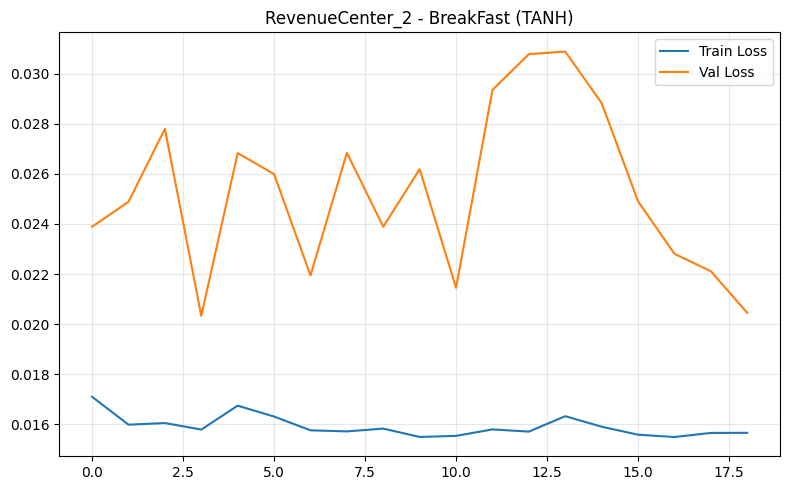

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


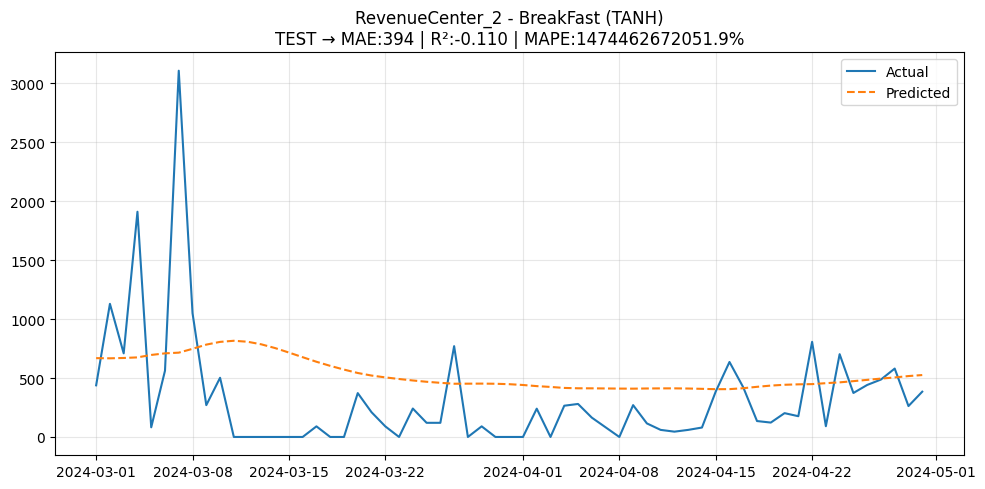

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 126ms/step - loss: 0.0193 - val_loss: 0.0527
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - loss: 0.0151 - val_loss: 0.0677
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - loss: 0.0167 - val_loss: 0.0723
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - loss: 0.0171 - val_loss: 0.0621
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - loss: 0.0146 - val_loss: 0.0739
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 124ms/step - loss: 0.0182 - val_loss: 0.0630
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - loss: 0.0150 - val_loss: 0.0644
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - loss: 0.0138 - val_loss: 0.0594
Epoch 9/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - loss: 0.0144 - val_loss: 0.0625
Epoch 10/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 116ms/step - loss: 0.0163 - val_loss: 0.0577
Epoch 11/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 127ms/step - loss: 0.0196 - val_loss: 0.0591
Epoch 12/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 99ms/step - los

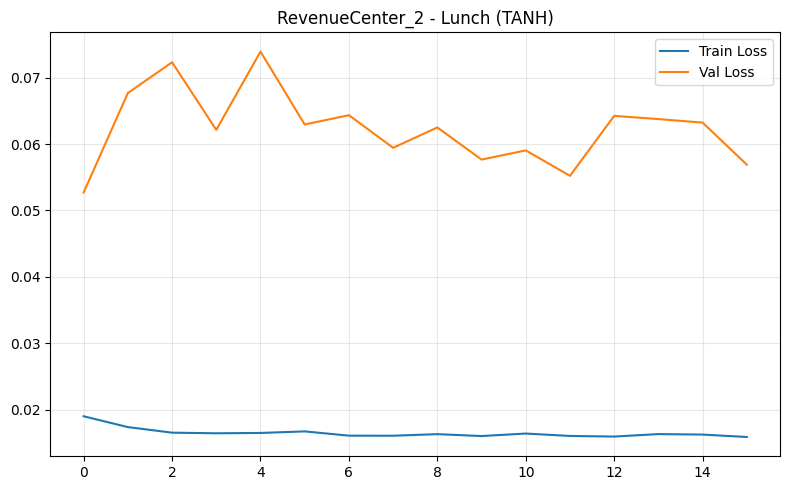

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


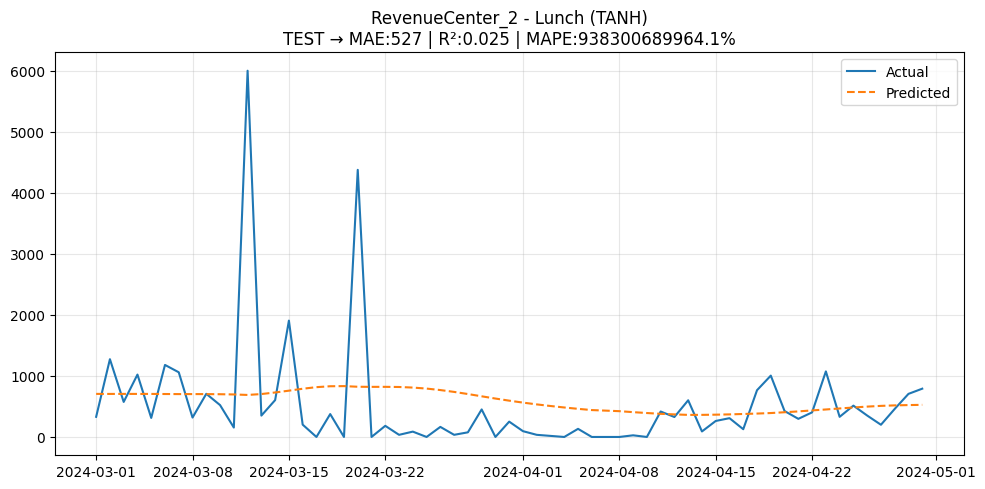

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 143ms/step - loss: 0.0030 - val_loss: 0.0304
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 102ms/step - loss: 0.0028 - val_loss: 0.0288
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 103ms/step - loss: 0.0016 - val_loss: 0.0278
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - loss: 0.0021 - val_loss: 0.0278
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 126ms/step - loss: 0.0017 - val_loss: 0.0290
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - loss: 0.0014 - val_loss: 0.0256
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - loss: 0.0018 - val_loss: 0.0269
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - loss: 0.0023 - val_loss: 0.0292
Epoch 9/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 104ms/step - loss: 0.0021 - val_loss: 0.0284
Epoch 10/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 108ms/step - loss: 0.0026 - val_loss: 0.0280
Epoch 11/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - loss: 0.0021 - val_loss: 0.0284
Epoch 12/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 97ms/step - 

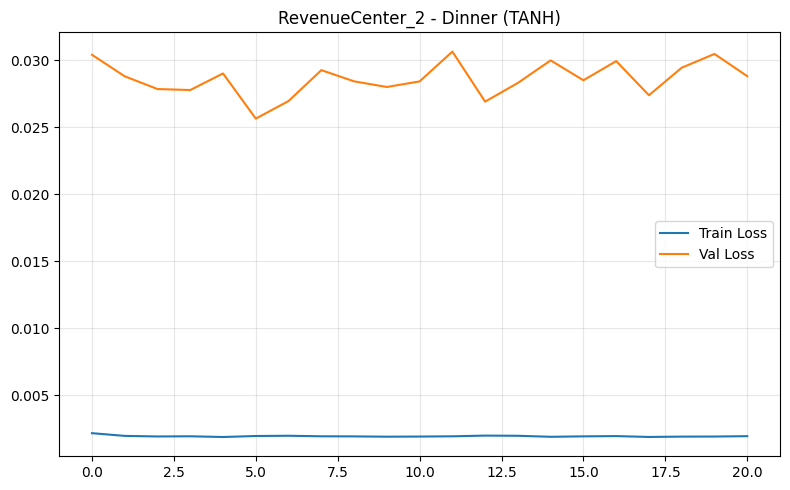

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


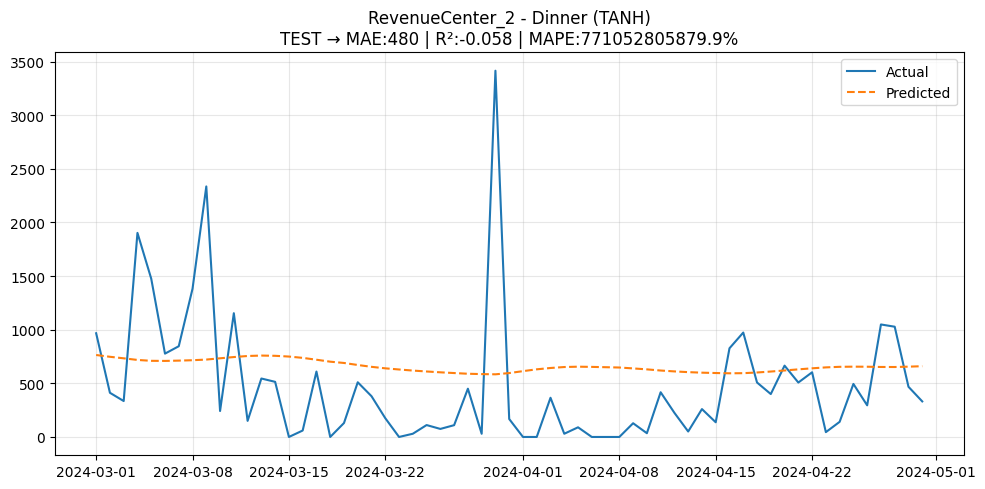

Saved: /content/RevenueCenter_2

Processing: RevenueCenter_8
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 160ms/step - loss: 0.0066 - val_loss: 0.0031
Epoch 2/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 104ms/step - loss: 0.0065 - val_loss: 0.0035
Epoch 3/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 108ms/step - loss: 0.0114 - val_loss: 0.0023
Epoch 4/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step - loss: 0.0047 - val_loss: 0.0032
Epoch 5/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 103ms/step - loss: 0.0098 - val_loss: 0.0026
Epoch 6/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 120ms/step - loss: 0.0060 - val_loss: 0.0027
Epoch 7/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step - loss: 0.0166 - val_loss: 0.0024
Epoch 8/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 105ms/step - loss: 0.0084 - val_loss: 0.0024
Epoch 9/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step - loss: 0.0108 - val_loss: 0.0023
Epoch 10/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 111ms/step - loss: 0.0113 - val_loss: 0.0023
Epoch 11/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 118ms/step - loss: 0.0080 - val_loss: 0.0024
Epoch 12/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step 

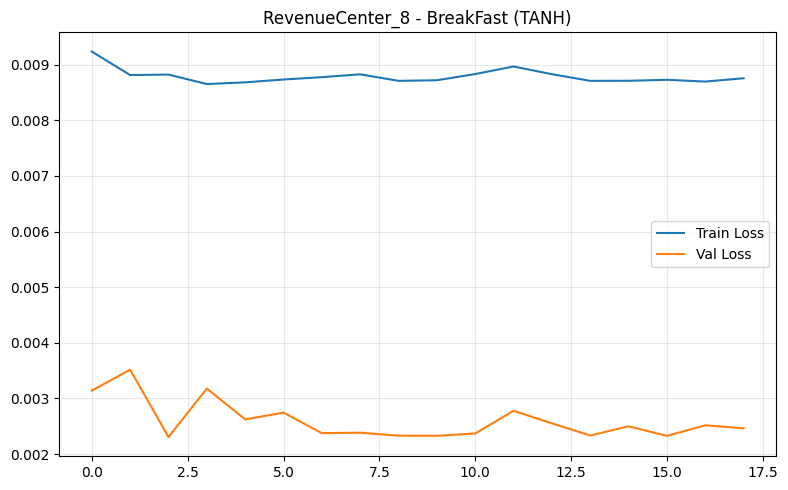

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


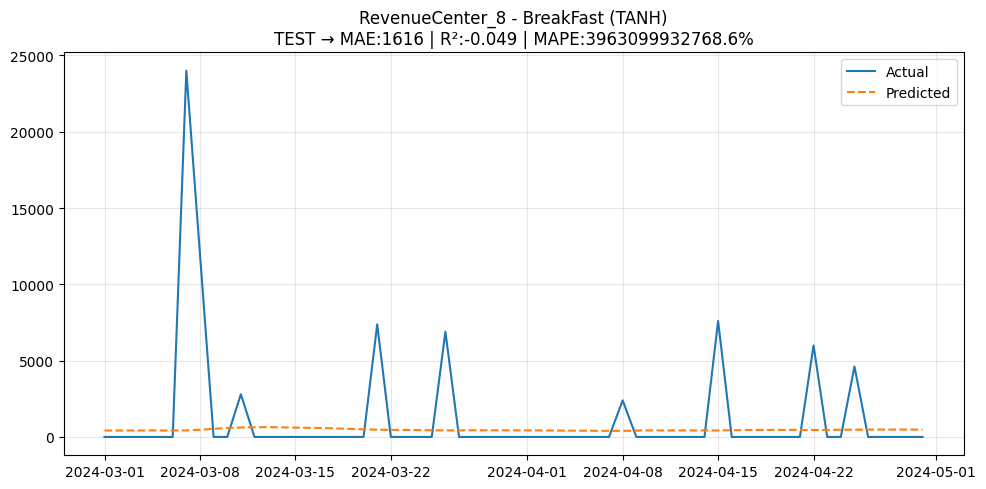

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 153ms/step - loss: 0.0178 - val_loss: 0.0994
Epoch 2/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 103ms/step - loss: 0.0188 - val_loss: 0.1097
Epoch 3/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - loss: 0.0149 - val_loss: 0.1035
Epoch 4/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 109ms/step - loss: 0.0170 - val_loss: 0.1082
Epoch 5/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - loss: 0.0129 - val_loss: 0.0969
Epoch 6/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 134ms/step - loss: 0.0144 - val_loss: 0.1037
Epoch 7/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step - loss: 0.0129 - val_loss: 0.0956
Epoch 8/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - loss: 0.0140 - val_loss: 0.1036
Epoch 9/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 115ms/step - loss: 0.0177 - val_loss: 0.1065
Epoch 10/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 118ms/step - loss: 0.0162 - val_loss: 0.1046
Epoch 11/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 141ms/step - loss: 0.0179 - val_loss: 0.1079
Epoch 12/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step

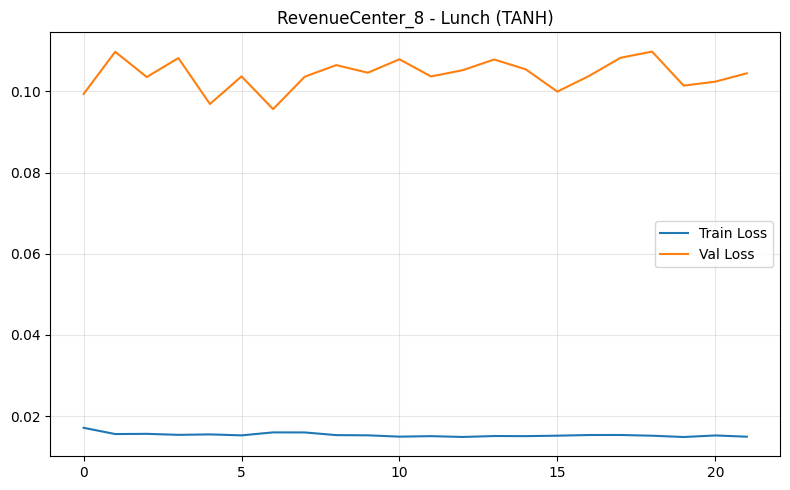

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


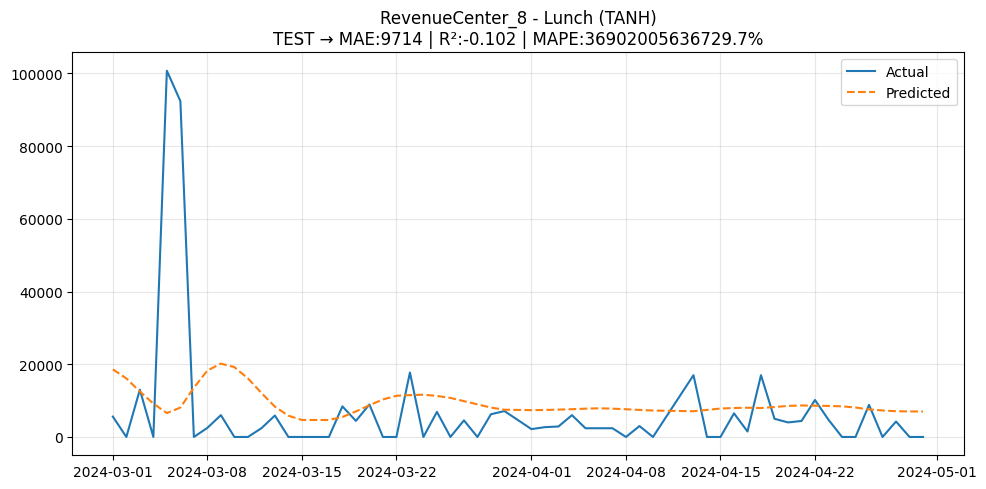

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 168ms/step - loss: 0.0175 - val_loss: 0.0583
Epoch 2/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 112ms/step - loss: 0.0144 - val_loss: 0.0562
Epoch 3/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 110ms/step - loss: 0.0106 - val_loss: 0.0500
Epoch 4/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step - loss: 0.0134 - val_loss: 0.0542
Epoch 5/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - loss: 0.0155 - val_loss: 0.0569
Epoch 6/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 141ms/step - loss: 0.0141 - val_loss: 0.0531
Epoch 7/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step - loss: 0.0133 - val_loss: 0.0623
Epoch 8/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 107ms/step - loss: 0.0135 - val_loss: 0.0584
Epoch 9/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 113ms/step - loss: 0.0136 - val_loss: 0.0565
Epoch 10/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step - loss: 0.0144 - val_loss: 0.0530
Epoch 11/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 143ms/step - loss: 0.0124 - val_loss: 0.0542
Epoch 12/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 113ms/step

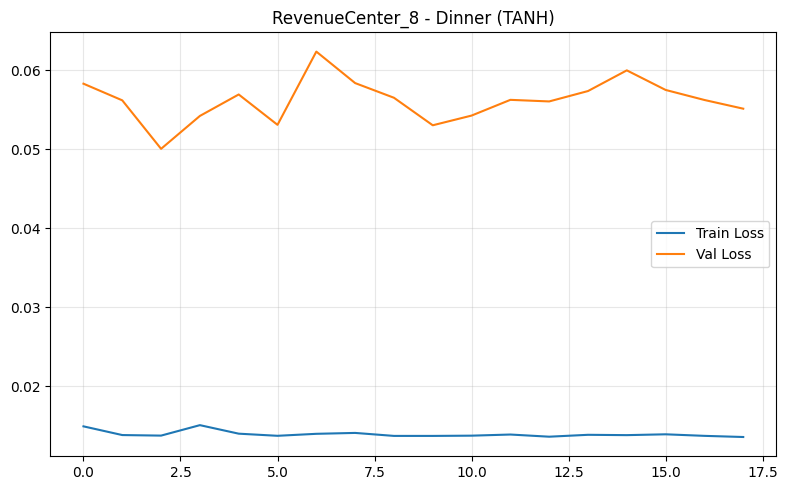

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


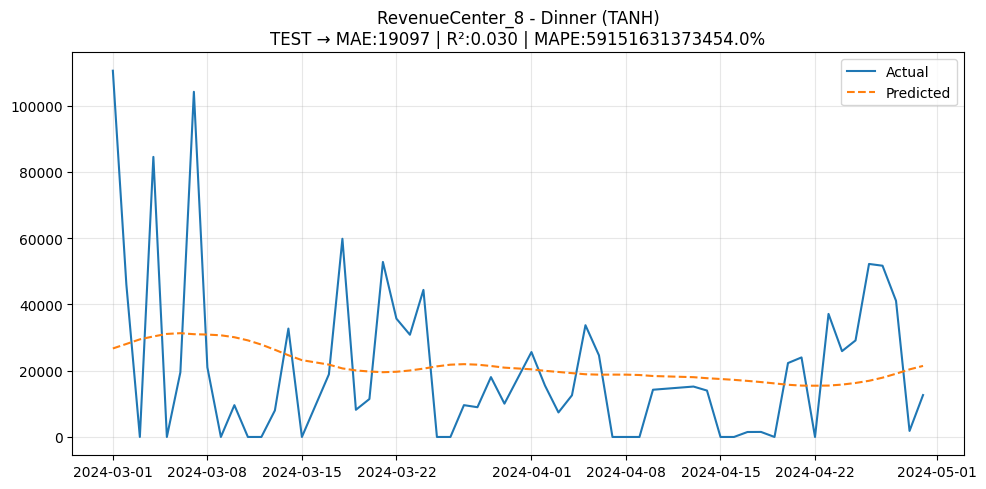

Saved: /content/RevenueCenter_8

Processing: RevenueCenter_7
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 128ms/step - loss: 0.0112 - val_loss: 0.0046
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - loss: 0.0104 - val_loss: 0.0046
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - loss: 0.0100 - val_loss: 0.0045
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 108ms/step - loss: 0.0074 - val_loss: 0.0044
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 135ms/step - loss: 0.0080 - val_loss: 0.0045
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 107ms/step - loss: 0.0075 - val_loss: 0.0049
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - loss: 0.0082 - val_loss: 0.0047
Epoch 8/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 108ms/step - loss: 0.0084 - val_loss: 0.0043
Epoch 9/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 107ms/step - loss: 0.0078 - val_loss: 0.0044
Epoch 10/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 133ms/step - loss: 0.0120 - val_loss: 0.0044
Epoch 11/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 110ms/step - loss: 0.0104 - val_loss: 0.0044
Epoch 12/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 103ms/step 

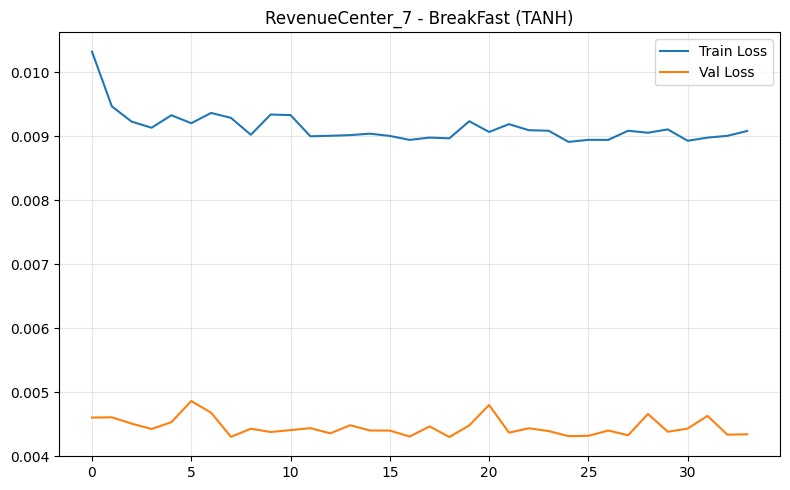

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


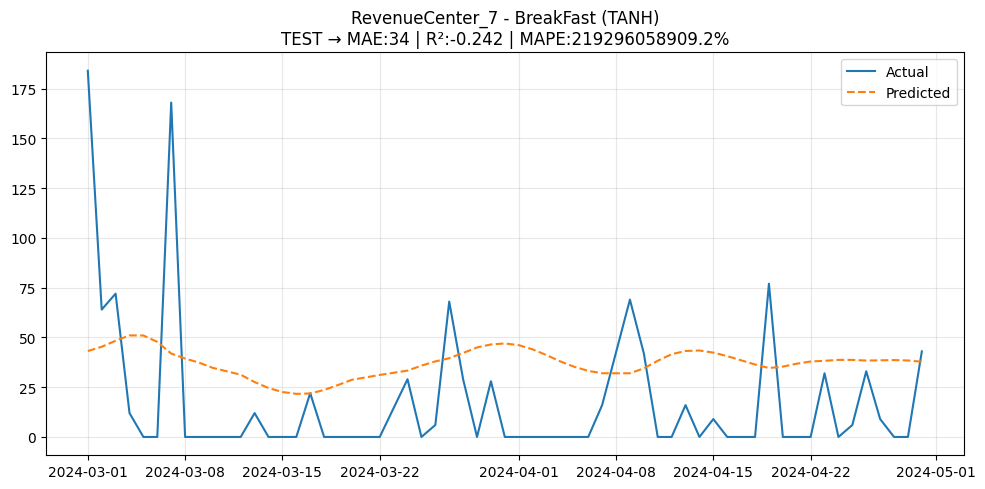

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 128ms/step - loss: 0.0150 - val_loss: 0.0432
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step - loss: 0.0116 - val_loss: 0.0425
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 116ms/step - loss: 0.0094 - val_loss: 0.0411
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 119ms/step - loss: 0.0088 - val_loss: 0.0401
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 103ms/step - loss: 0.0097 - val_loss: 0.0406
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - loss: 0.0104 - val_loss: 0.0411
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step - loss: 0.0097 - val_loss: 0.0400
Epoch 8/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 129ms/step - loss: 0.0116 - val_loss: 0.0426
Epoch 9/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - loss: 0.0106 - val_loss: 0.0412
Epoch 10/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - loss: 0.0103 - val_loss: 0.0414
Epoch 11/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - loss: 0.0094 - val_loss: 0.0409
Epoch 12/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 108ms/step - 

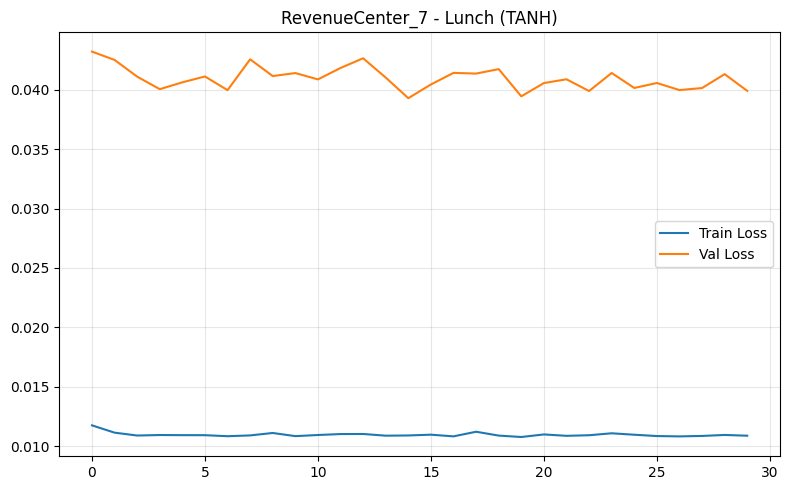

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


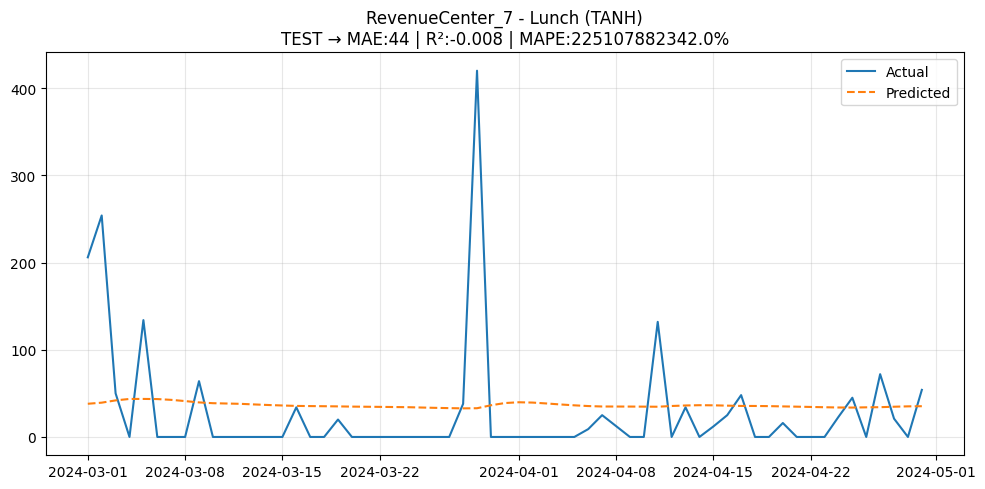

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 126ms/step - loss: 0.0219 - val_loss: 0.0926
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step - loss: 0.0206 - val_loss: 0.0944
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 104ms/step - loss: 0.0164 - val_loss: 0.0803
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 130ms/step - loss: 0.0183 - val_loss: 0.0791
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step - loss: 0.0183 - val_loss: 0.0829
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 103ms/step - loss: 0.0200 - val_loss: 0.0810
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step - loss: 0.0179 - val_loss: 0.0895
Epoch 8/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 114ms/step - loss: 0.0223 - val_loss: 0.0943
Epoch 9/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 145ms/step - loss: 0.0185 - val_loss: 0.0830
Epoch 10/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 108ms/step - loss: 0.0186 - val_loss: 0.0882
Epoch 11/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 105ms/step - loss: 0.0192 - val_loss: 0.0862
Epoch 12/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step

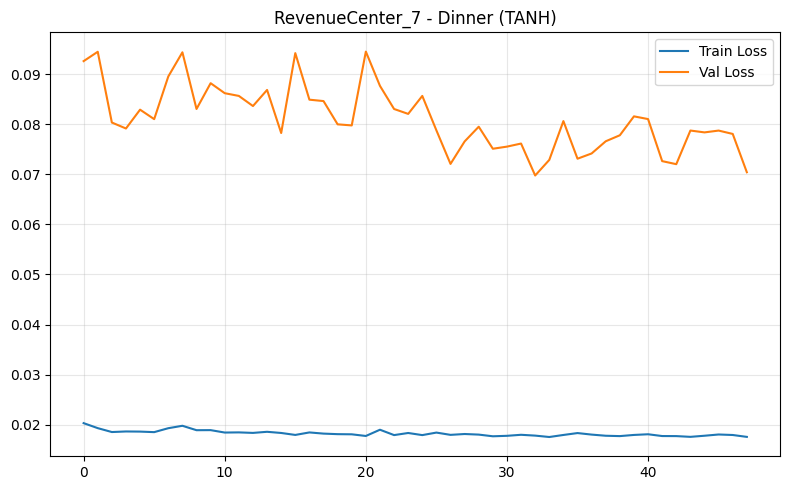

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


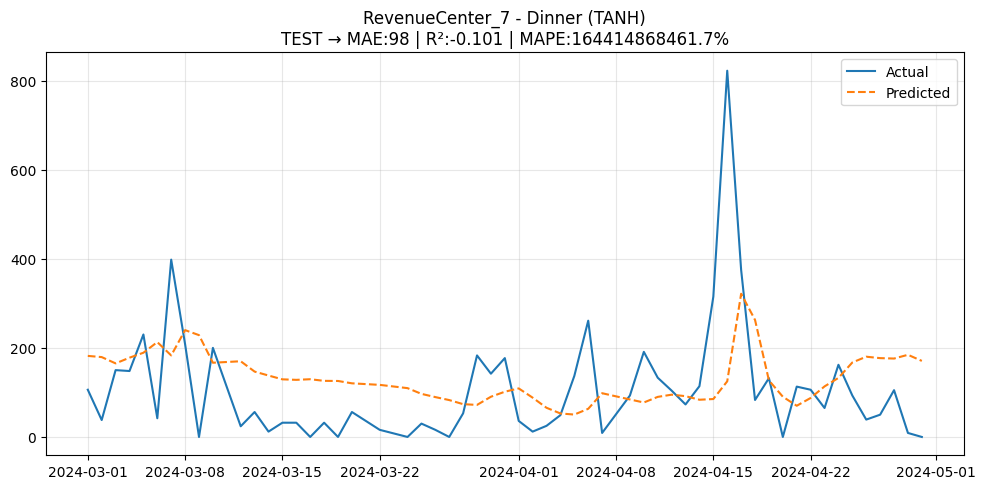

Saved: /content/RevenueCenter_7

Processing: RevenueCenter_6
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 135ms/step - loss: 0.0199 - val_loss: 0.0493
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 121ms/step - loss: 0.0243 - val_loss: 0.0485
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 107ms/step - loss: 0.0269 - val_loss: 0.0498
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 125ms/step - loss: 0.0257 - val_loss: 0.0494
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 131ms/step - loss: 0.0229 - val_loss: 0.0499
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step - loss: 0.0249 - val_loss: 0.0523
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 109ms/step - loss: 0.0226 - val_loss: 0.0521
Epoch 8/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step - loss: 0.0234 - val_loss: 0.0513
Epoch 9/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step - loss: 0.0227 - val_loss: 0.0494
Epoch 10/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 127ms/step - loss: 0.0225 - val_loss: 0.0499
Epoch 11/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - loss: 0.0238 - val_loss: 0.0508
Epoch 12/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 109ms/step

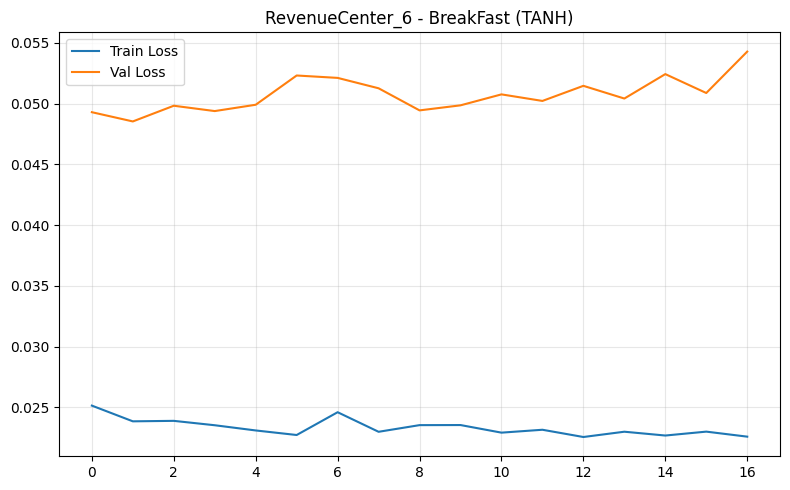

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


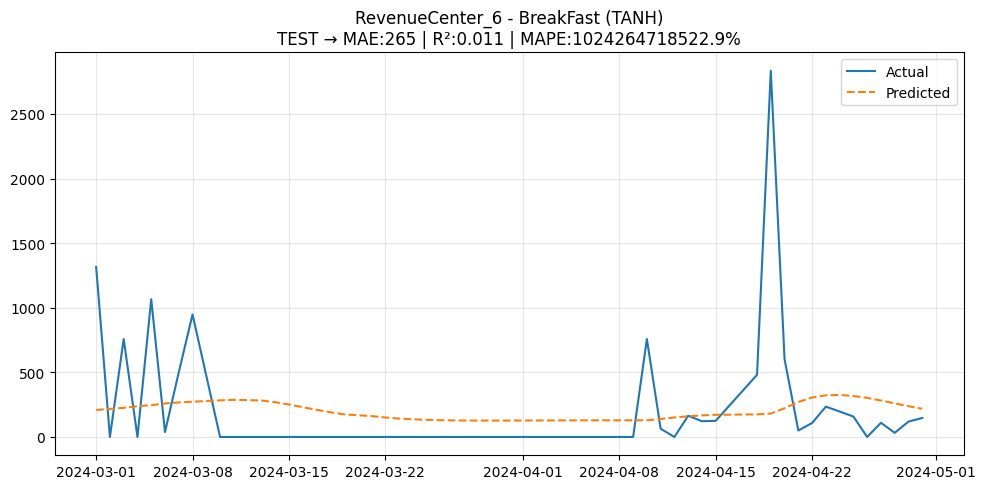

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 129ms/step - loss: 0.0146 - val_loss: 0.0179
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 131ms/step - loss: 0.0147 - val_loss: 0.0190
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step - loss: 0.0153 - val_loss: 0.0232
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step - loss: 0.0115 - val_loss: 0.0191
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step - loss: 0.0108 - val_loss: 0.0210
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 103ms/step - loss: 0.0173 - val_loss: 0.0207
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 131ms/step - loss: 0.0105 - val_loss: 0.0195
Epoch 8/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 110ms/step - loss: 0.0094 - val_loss: 0.0197
Epoch 9/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step - loss: 0.0099 - val_loss: 0.0207
Epoch 10/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step - loss: 0.0088 - val_loss: 0.0202
Epoch 11/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 130ms/step - loss: 0.0115 - val_loss: 0.0195
Epoch 12/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 107ms/step

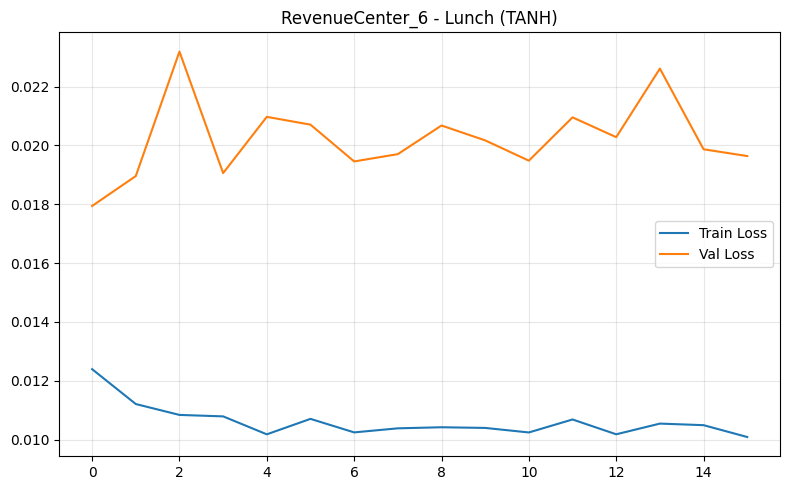

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


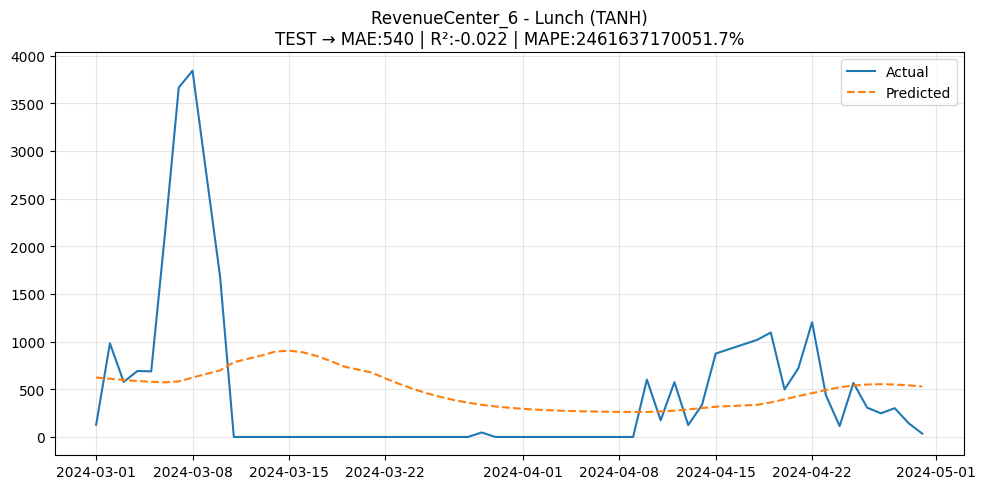

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 153ms/step - loss: 0.0035 - val_loss: 0.0251
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 104ms/step - loss: 0.0025 - val_loss: 0.0251
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 110ms/step - loss: 0.0050 - val_loss: 0.0253
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 119ms/step - loss: 0.0028 - val_loss: 0.0246
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 120ms/step - loss: 0.0031 - val_loss: 0.0247
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 111ms/step - loss: 0.0021 - val_loss: 0.0251
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 104ms/step - loss: 0.0026 - val_loss: 0.0248
Epoch 8/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step - loss: 8.9663e-04 - val_loss: 0.0245
Epoch 9/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 137ms/step - loss: 0.0014 - val_loss: 0.0247
Epoch 10/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step - loss: 0.0048 - val_loss: 0.0246
Epoch 11/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 103ms/step - loss: 0.0013 - val_loss: 0.0245
Epoch 12/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 109ms/

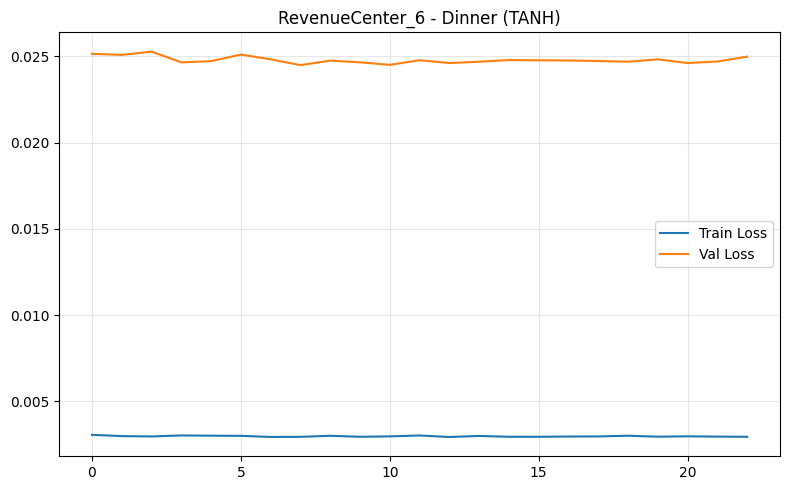

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


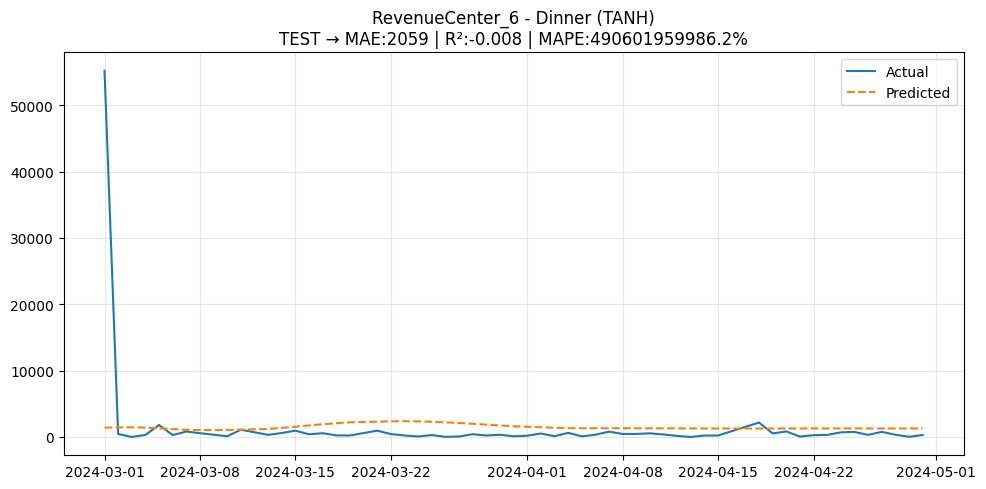

Saved: /content/RevenueCenter_6

Processing: RevenueCenter_5
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 124ms/step - loss: 0.0352 - val_loss: 0.0507
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 136ms/step - loss: 0.0097 - val_loss: 0.0153
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 112ms/step - loss: 0.0082 - val_loss: 0.0243
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 109ms/step - loss: 0.0076 - val_loss: 0.0170
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 118ms/step - loss: 0.0087 - val_loss: 0.0182
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 128ms/step - loss: 0.0073 - val_loss: 0.0227
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 119ms/step - loss: 0.0076 - val_loss: 0.0179
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 119ms/step - loss: 0.0083 - val_loss: 0.0188
Epoch 9/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 140ms/step - loss: 0.0069 - val_loss: 0.0176
Epoch 10/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 114ms/step - loss: 0.0053 - val_loss: 0.0279
Epoch 11/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 116ms/step - loss: 0.0082 - val_loss: 0.0335
Epoch 12/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 116ms/step

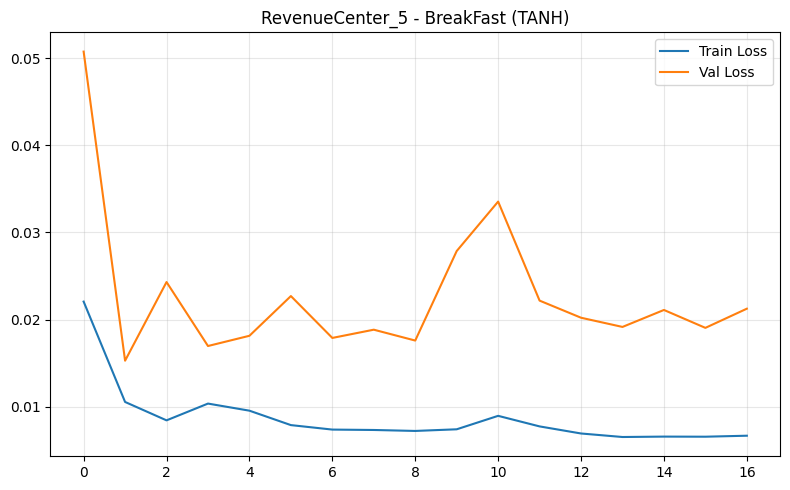

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


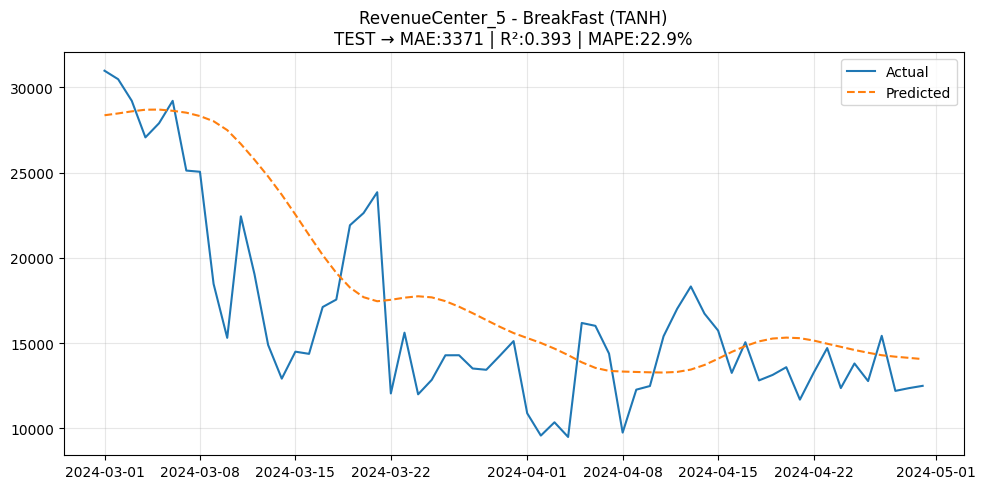

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 157ms/step - loss: 0.0228 - val_loss: 0.0170
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 125ms/step - loss: 0.0145 - val_loss: 0.0170
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 111ms/step - loss: 0.0116 - val_loss: 0.0161
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 140ms/step - loss: 0.0125 - val_loss: 0.0162
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 108ms/step - loss: 0.0177 - val_loss: 0.0170
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 110ms/step - loss: 0.0133 - val_loss: 0.0166
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 118ms/step - loss: 0.0160 - val_loss: 0.0172
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 127ms/step - loss: 0.0202 - val_loss: 0.0183
Epoch 9/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 119ms/step - loss: 0.0098 - val_loss: 0.0164
Epoch 10/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 110ms/step - loss: 0.0138 - val_loss: 0.0167
Epoch 11/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 129ms/step - loss: 0.0220 - val_loss: 0.0181
Epoch 12/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 113ms/step

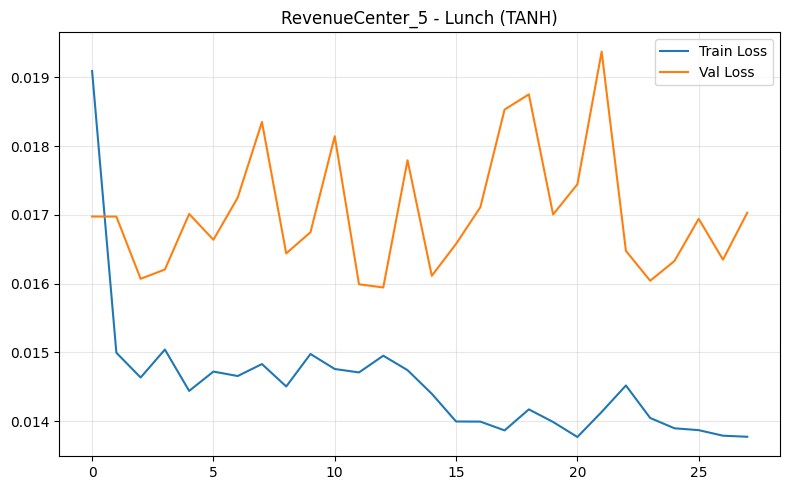

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


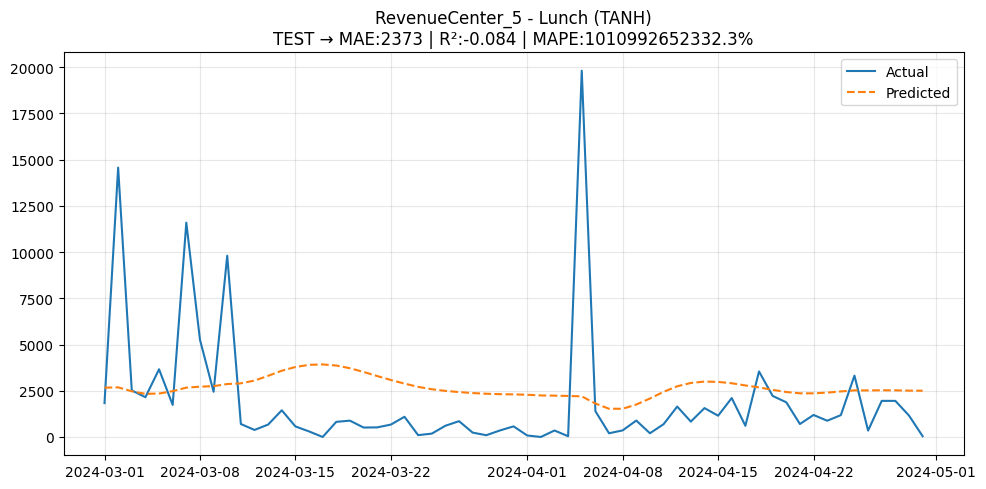

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 134ms/step - loss: 0.0335 - val_loss: 0.0617
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 118ms/step - loss: 0.0225 - val_loss: 0.0599
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 113ms/step - loss: 0.0169 - val_loss: 0.0574
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 108ms/step - loss: 0.0191 - val_loss: 0.0576
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 111ms/step - loss: 0.0206 - val_loss: 0.0610
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 136ms/step - loss: 0.0200 - val_loss: 0.0587
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 113ms/step - loss: 0.0176 - val_loss: 0.0590
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 107ms/step - loss: 0.0203 - val_loss: 0.0645
Epoch 9/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 104ms/step - loss: 0.0132 - val_loss: 0.0637
Epoch 10/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 124ms/step - loss: 0.0216 - val_loss: 0.0665
Epoch 11/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 114ms/step - loss: 0.0200 - val_loss: 0.0660
Epoch 12/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 108ms/step

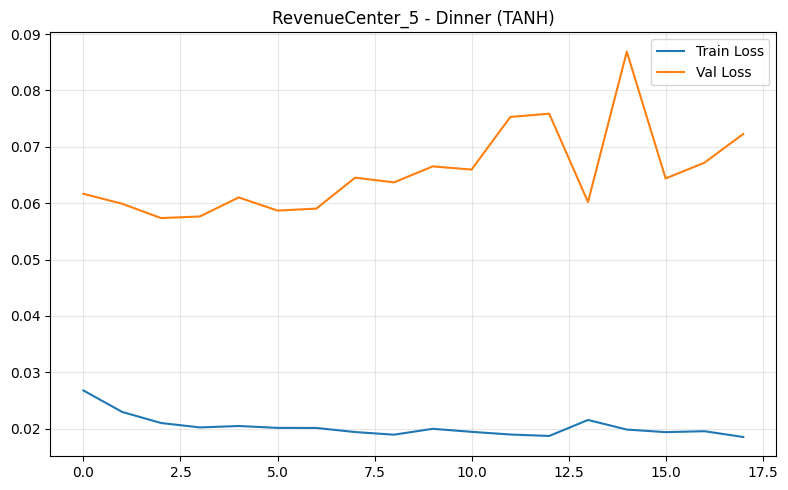

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step


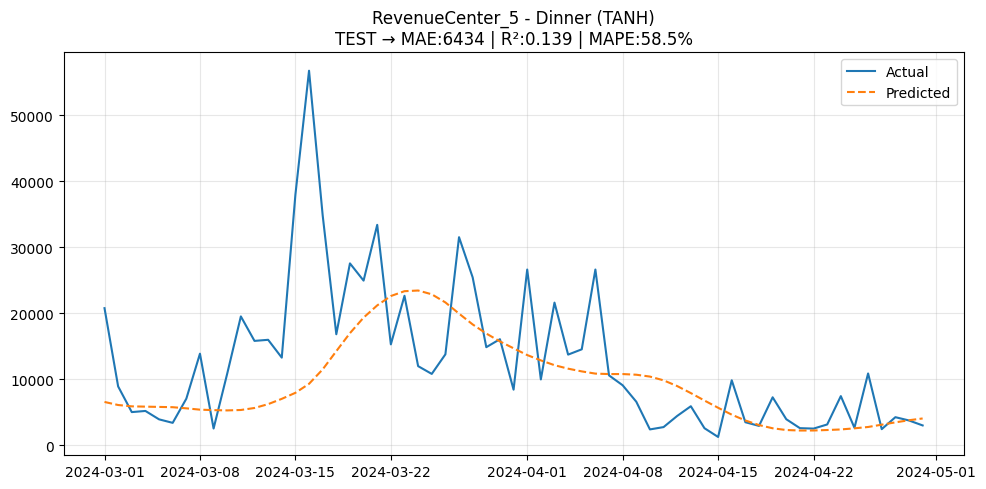

Saved: /content/RevenueCenter_5

Processing: RevenueCenter_3
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 128ms/step - loss: 0.0269 - val_loss: 0.0440
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 111ms/step - loss: 0.0255 - val_loss: 0.0413
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 132ms/step - loss: 0.0287 - val_loss: 0.0453
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 112ms/step - loss: 0.0280 - val_loss: 0.0425
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 112ms/step - loss: 0.0265 - val_loss: 0.0387
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 111ms/step - loss: 0.0241 - val_loss: 0.0376
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 132ms/step - loss: 0.0235 - val_loss: 0.0405
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 109ms/step - loss: 0.0223 - val_loss: 0.0406
Epoch 9/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 104ms/step - loss: 0.0223 - val_loss: 0.0427
Epoch 10/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 107ms/step - loss: 0.0218 - val_loss: 0.0385
Epoch 11/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 110ms/step - loss: 0.0230 - val_loss: 0.0382
Epoch 12/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 130ms/step

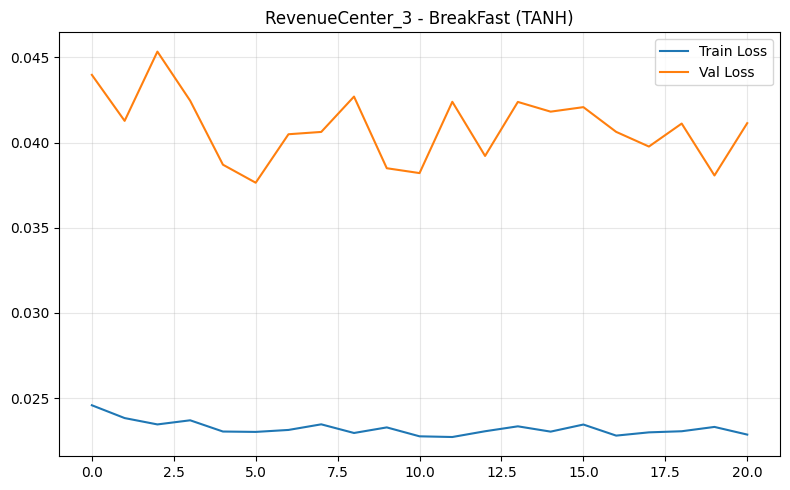

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


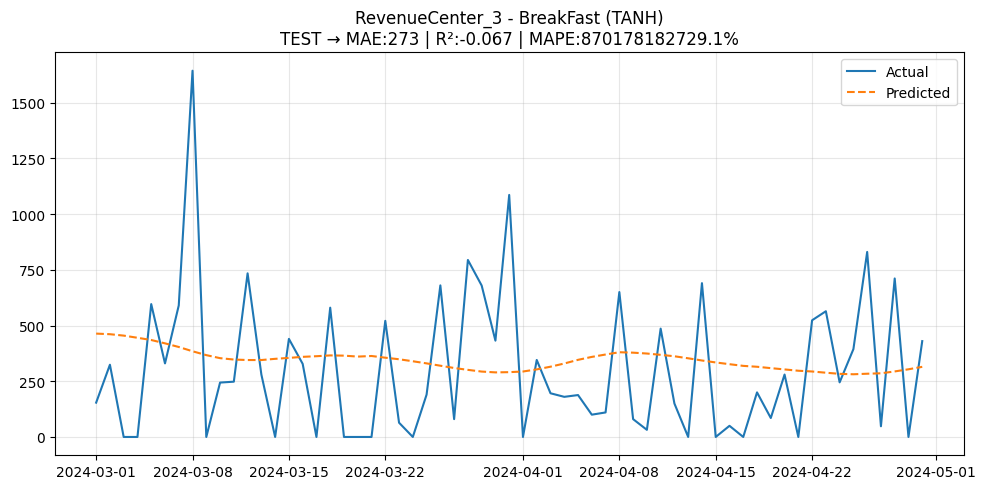

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 129ms/step - loss: 0.0171 - val_loss: 0.0551
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 111ms/step - loss: 0.0101 - val_loss: 0.0585
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 108ms/step - loss: 0.0088 - val_loss: 0.0555
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 131ms/step - loss: 0.0089 - val_loss: 0.0581
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 107ms/step - loss: 0.0100 - val_loss: 0.0540
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 112ms/step - loss: 0.0093 - val_loss: 0.0564
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 110ms/step - loss: 0.0110 - val_loss: 0.0688
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 124ms/step - loss: 0.0095 - val_loss: 0.0662
Epoch 9/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 116ms/step - loss: 0.0096 - val_loss: 0.0581
Epoch 10/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 107ms/step - loss: 0.0096 - val_loss: 0.0640
Epoch 11/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 116ms/step - loss: 0.0132 - val_loss: 0.0607
Epoch 12/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 108ms/step

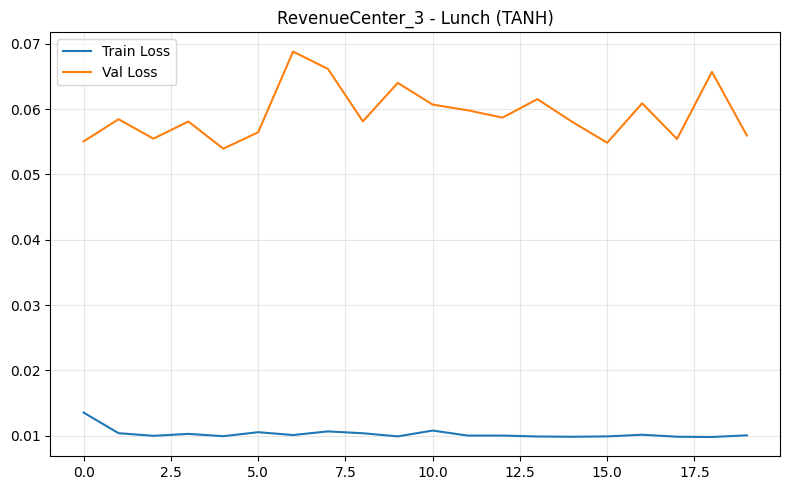

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


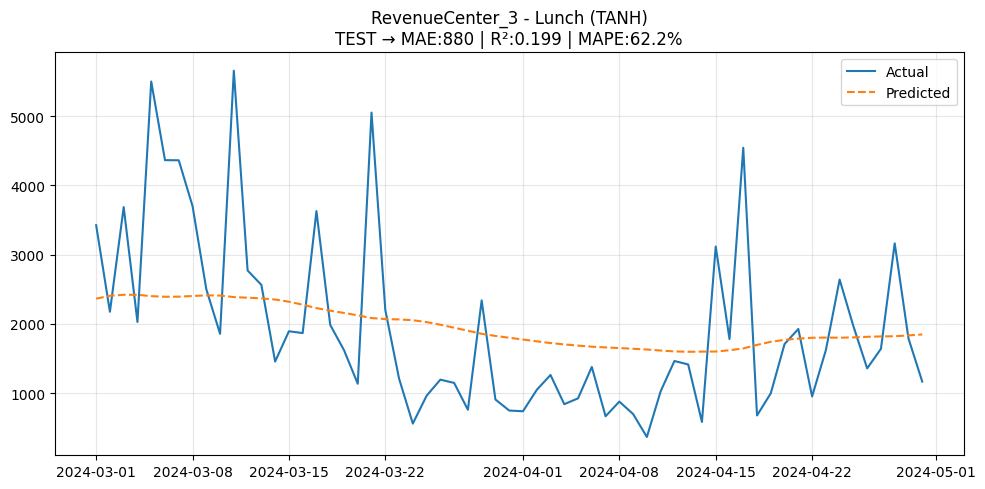

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 130ms/step - loss: 0.0279 - val_loss: 0.0814
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 115ms/step - loss: 0.0122 - val_loss: 0.0690
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 125ms/step - loss: 0.0115 - val_loss: 0.0323
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 111ms/step - loss: 0.0129 - val_loss: 0.0290
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 112ms/step - loss: 0.0131 - val_loss: 0.0354
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 130ms/step - loss: 0.0102 - val_loss: 0.0599
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step - loss: 0.0127 - val_loss: 0.0443
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step - loss: 0.0091 - val_loss: 0.0436
Epoch 9/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 107ms/step - loss: 0.0099 - val_loss: 0.0349
Epoch 10/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 107ms/step - loss: 0.0099 - val_loss: 0.0308
Epoch 11/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 133ms/step - loss: 0.0107 - val_loss: 0.0444
Epoch 12/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step

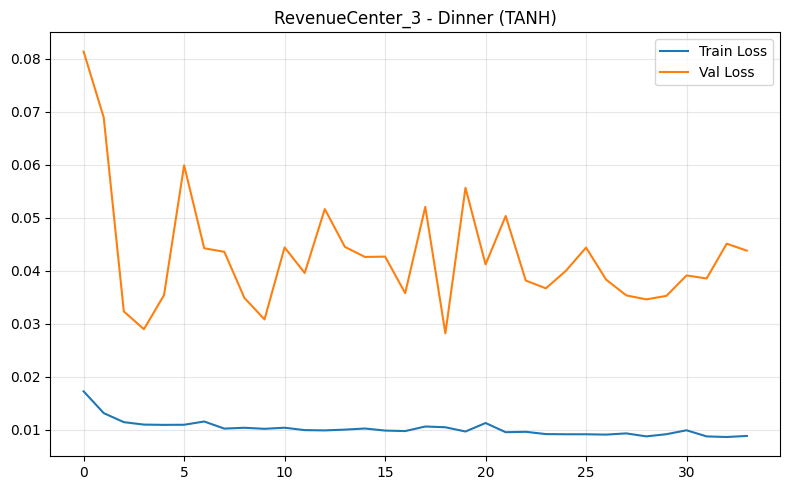

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


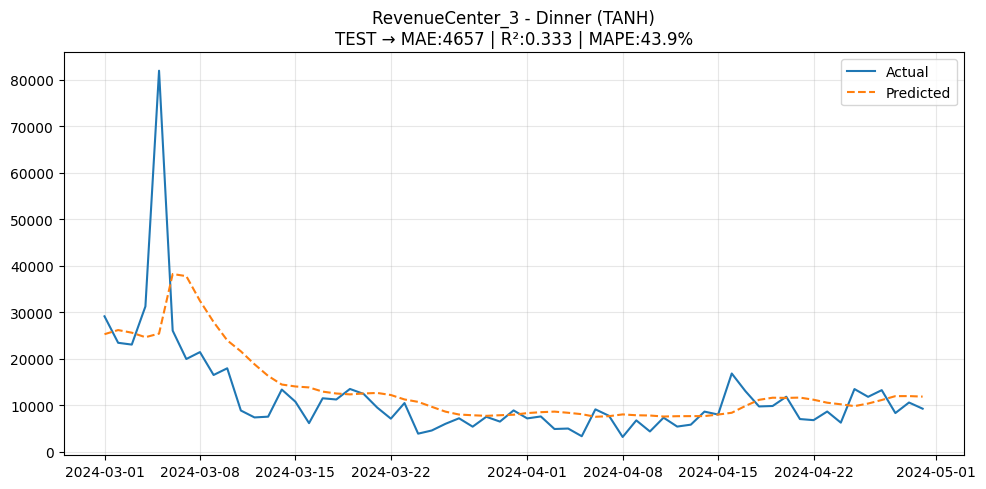

Saved: /content/RevenueCenter_3

Processing: RevenueCenter_4
Skipping RevenueCenter_4 - BreakFast (constant values)
Skipping RevenueCenter_4 - Lunch (constant values)
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 135ms/step - loss: 0.0012 - val_loss: 4.9287e-08
Epoch 2/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 116ms/step - loss: 0.0018 - val_loss: 3.0895e-06
Epoch 3/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 118ms/step - loss: 0.0040 - val_loss: 1.6590e-06
Epoch 4/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 131ms/step - loss: 0.0035 - val_loss: 1.6543e-05
Epoch 5/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 110ms/step - loss: 9.8186e-04 - val_loss: 8.7702e-05
Epoch 6/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 115ms/step - loss: 9.9987e-04 - val_loss: 9.4015e-05
Epoch 7/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 110ms/step - loss: 0.0101 - val_loss: 1.2519e-06
Epoch 8/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 138ms/step - loss: 0.0031 - val_loss: 2.0195e-06
Epoch 9/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 109ms/step - loss: 9.7310e-04 - val_loss: 7.9233e-05
Epoch 10/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 109ms/step - loss: 0.0020 - val_loss: 5.7791e-06
Epoch 11/100
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 116ms/step - loss: 0.0011 - val_loss: 8.4112e-

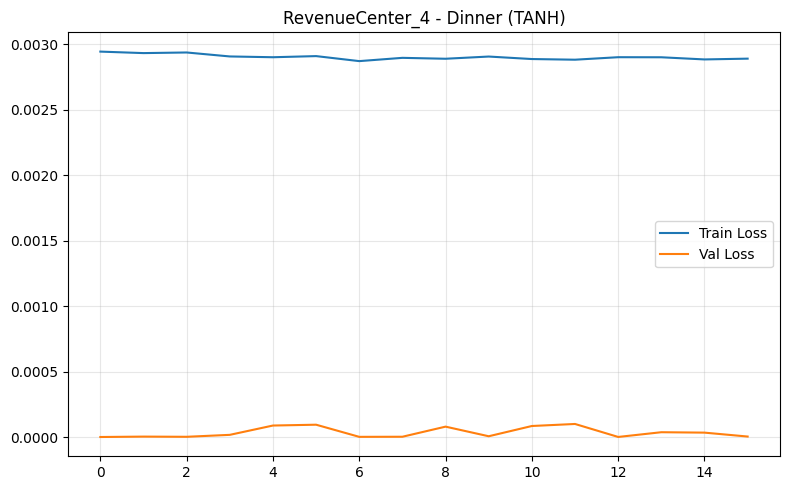

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


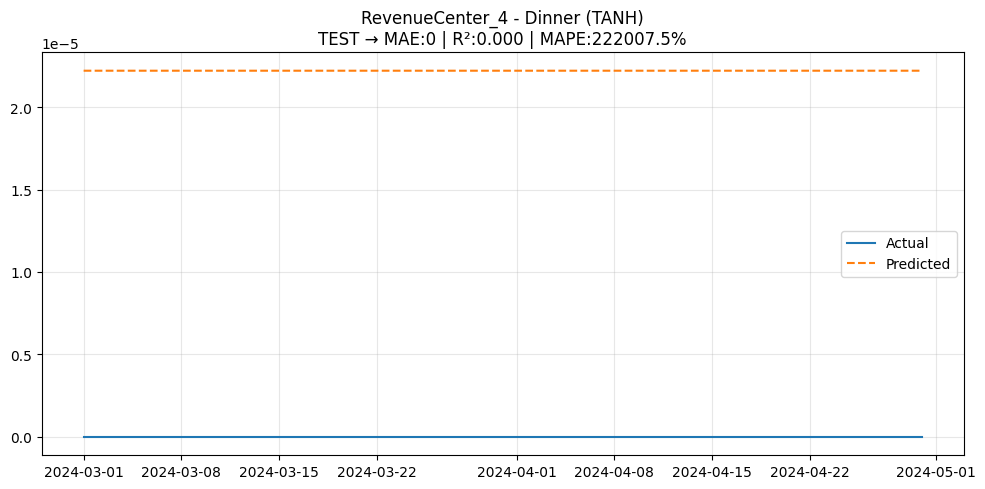

Saved: /content/RevenueCenter_4

Processing: RevenueCenter_9
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 142ms/step - loss: 0.0105 - val_loss: 0.1065
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 116ms/step - loss: 0.0095 - val_loss: 0.0880
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 122ms/step - loss: 0.0088 - val_loss: 0.0833
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 130ms/step - loss: 0.0108 - val_loss: 0.1114
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 114ms/step - loss: 0.0076 - val_loss: 0.0729
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 114ms/step - loss: 0.0101 - val_loss: 0.0857
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 127ms/step - loss: 0.0083 - val_loss: 0.0849
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 123ms/step - loss: 0.0077 - val_loss: 0.0716
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 111ms/step - loss: 0.0093 - val_loss: 0.0800
Epoch 10/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 116ms/step - loss: 0.0092 - val_loss: 0.0788
Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 112ms/step - loss: 0.0082 - val_loss: 0.0710
Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 149ms/step

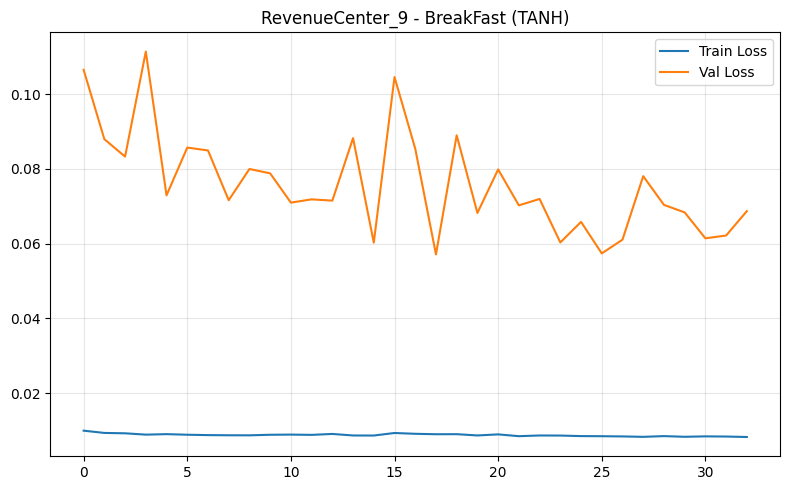

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


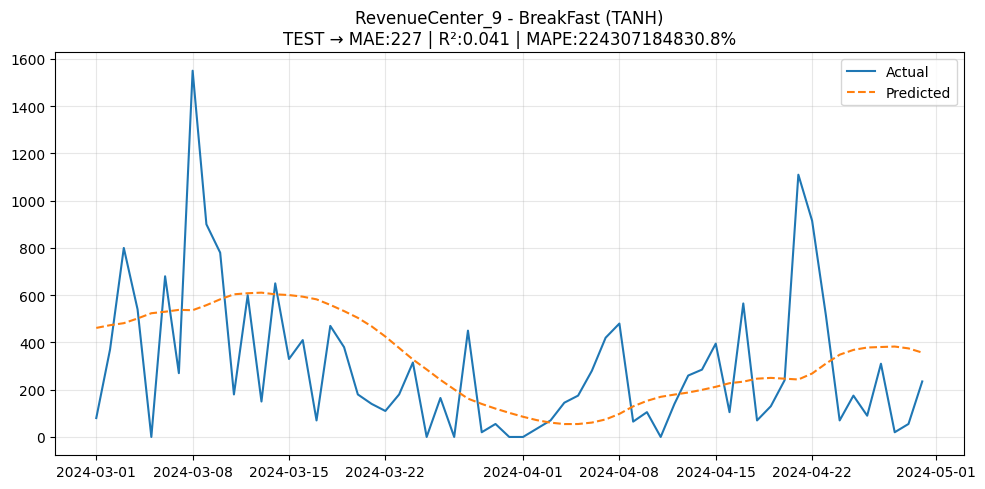

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 129ms/step - loss: 0.0368 - val_loss: 0.0474
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 113ms/step - loss: 0.0295 - val_loss: 0.0478
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 117ms/step - loss: 0.0358 - val_loss: 0.0474
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 131ms/step - loss: 0.0265 - val_loss: 0.0512
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 133ms/step - loss: 0.0338 - val_loss: 0.0503
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 118ms/step - loss: 0.0305 - val_loss: 0.0487
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 118ms/step - loss: 0.0331 - val_loss: 0.0493
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 120ms/step - loss: 0.0271 - val_loss: 0.0468
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 145ms/step - loss: 0.0315 - val_loss: 0.0500
Epoch 10/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 113ms/step - loss: 0.0371 - val_loss: 0.0485
Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 116ms/step - loss: 0.0307 - val_loss: 0.0484
Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 115ms/step

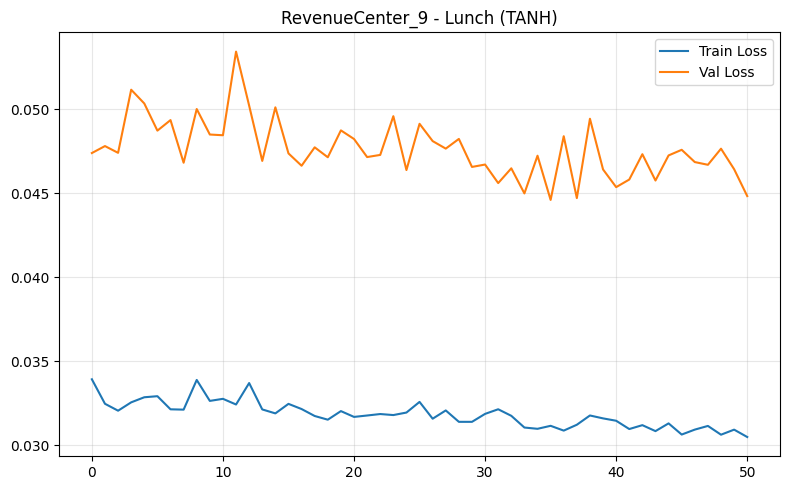

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


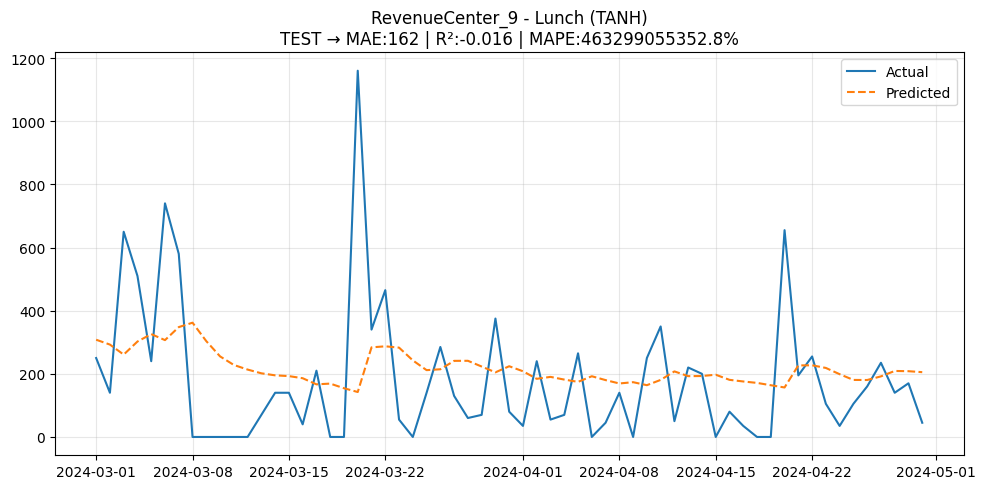

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 143ms/step - loss: 0.0260 - val_loss: 0.0133
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 116ms/step - loss: 0.0235 - val_loss: 0.0134
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 128ms/step - loss: 0.0268 - val_loss: 0.0132
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 136ms/step - loss: 0.0159 - val_loss: 0.0159
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 110ms/step - loss: 0.0258 - val_loss: 0.0140
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 111ms/step - loss: 0.0213 - val_loss: 0.0133
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 121ms/step - loss: 0.0274 - val_loss: 0.0136
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 127ms/step - loss: 0.0193 - val_loss: 0.0148
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 130ms/step - loss: 0.0168 - val_loss: 0.0145
Epoch 10/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 113ms/step - loss: 0.0170 - val_loss: 0.0151
Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 117ms/step - loss: 0.0266 - val_loss: 0.0143
Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 146ms/step

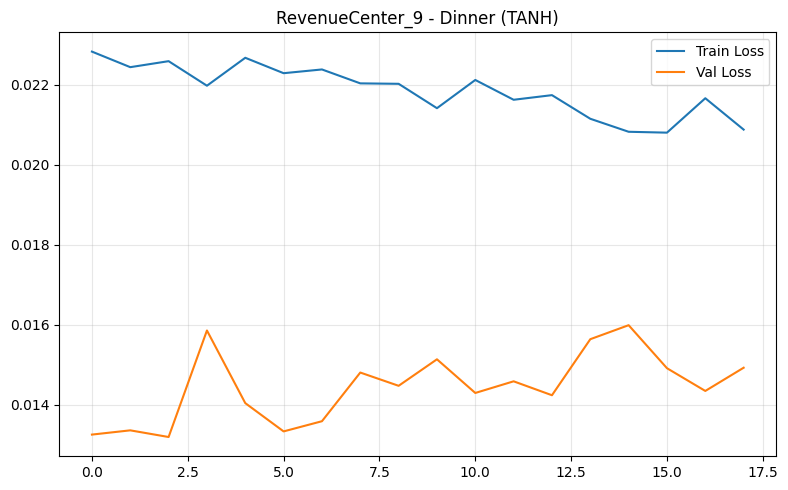

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step


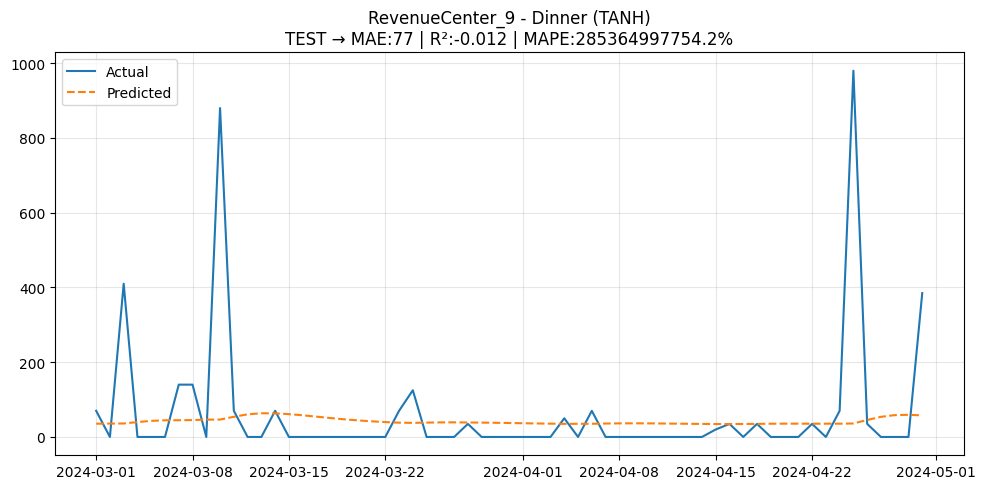

Saved: /content/RevenueCenter_9

Processing: RevenueCenter_1
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 164ms/step - loss: 0.0060 - val_loss: 0.0272
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 119ms/step - loss: 0.0046 - val_loss: 0.0274
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 114ms/step - loss: 0.0050 - val_loss: 0.0343
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 122ms/step - loss: 0.0045 - val_loss: 0.0374
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 136ms/step - loss: 0.0060 - val_loss: 0.0454
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 114ms/step - loss: 0.0061 - val_loss: 0.0339
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 111ms/step - loss: 0.0060 - val_loss: 0.0324
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 116ms/step - loss: 0.0051 - val_loss: 0.0295
Epoch 9/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 138ms/step - loss: 0.0042 - val_loss: 0.0294
Epoch 10/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 110ms/step - loss: 0.0041 - val_loss: 0.0309
Epoch 11/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 112ms/step - loss: 0.0050 - val_loss: 0.0318
Epoch 12/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 113ms/step

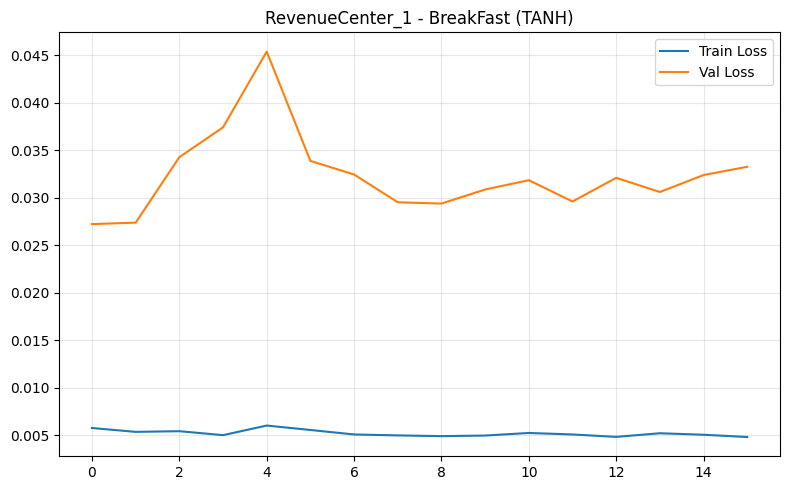

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


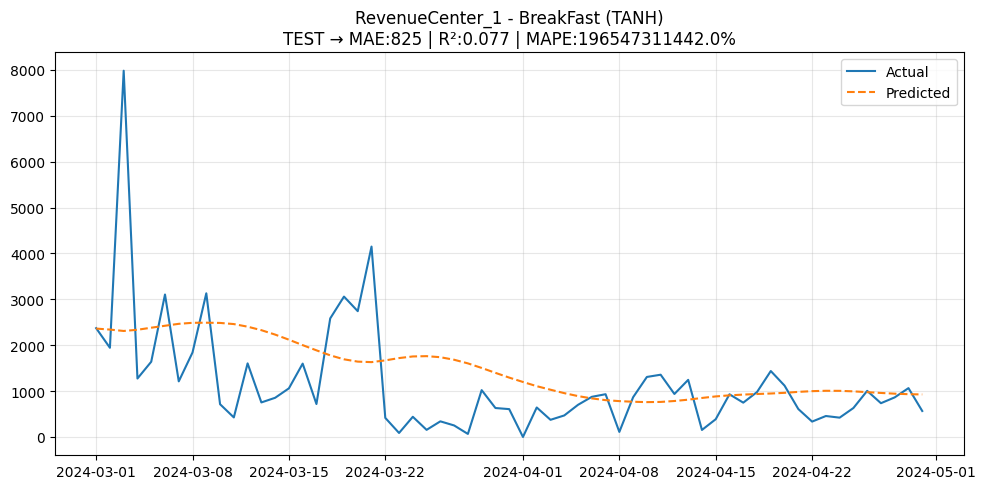

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 135ms/step - loss: 0.0176 - val_loss: 0.0694
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 142ms/step - loss: 0.0113 - val_loss: 0.0714
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 115ms/step - loss: 0.0141 - val_loss: 0.0820
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 115ms/step - loss: 0.0117 - val_loss: 0.0752
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 114ms/step - loss: 0.0151 - val_loss: 0.0924
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 145ms/step - loss: 0.0138 - val_loss: 0.0756
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 110ms/step - loss: 0.0122 - val_loss: 0.0768
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 114ms/step - loss: 0.0129 - val_loss: 0.0664
Epoch 9/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 113ms/step - loss: 0.0133 - val_loss: 0.0714
Epoch 10/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 133ms/step - loss: 0.0130 - val_loss: 0.0752
Epoch 11/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 118ms/step - loss: 0.0135 - val_loss: 0.0775
Epoch 12/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 114ms/step

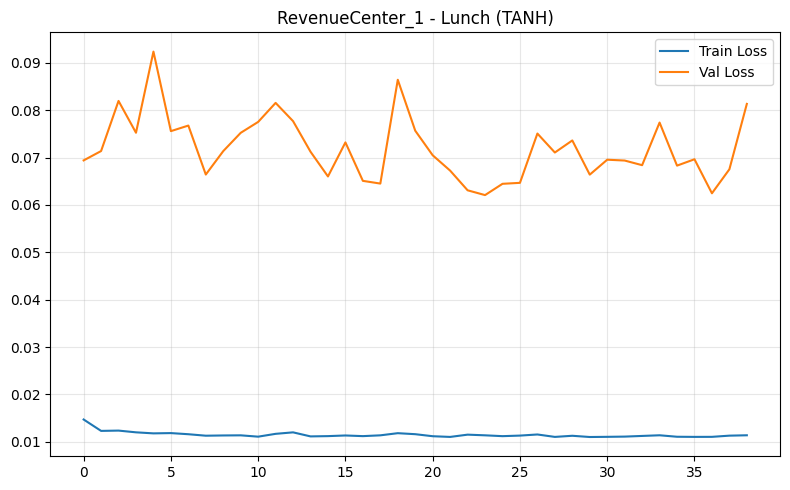

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


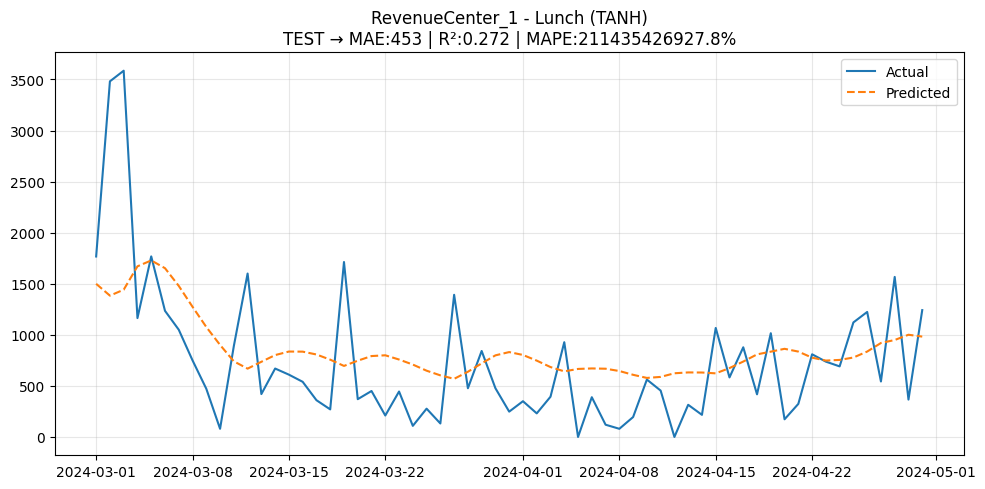

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 171ms/step - loss: 0.0231 - val_loss: 0.0286
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 124ms/step - loss: 0.0129 - val_loss: 0.0256
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 115ms/step - loss: 0.0173 - val_loss: 0.0460
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 131ms/step - loss: 0.0150 - val_loss: 0.0271
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 119ms/step - loss: 0.0132 - val_loss: 0.0547
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 123ms/step - loss: 0.0117 - val_loss: 0.0407
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 148ms/step - loss: 0.0112 - val_loss: 0.0315
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 119ms/step - loss: 0.0129 - val_loss: 0.0341
Epoch 9/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 117ms/step - loss: 0.0134 - val_loss: 0.0316
Epoch 10/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 113ms/step - loss: 0.0153 - val_loss: 0.0345
Epoch 11/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 149ms/step - loss: 0.0163 - val_loss: 0.0289
Epoch 12/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 120ms/step

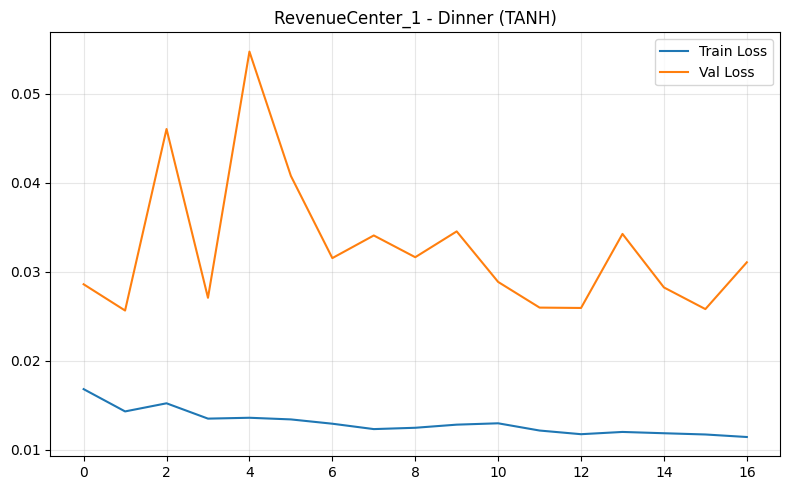

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 110ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


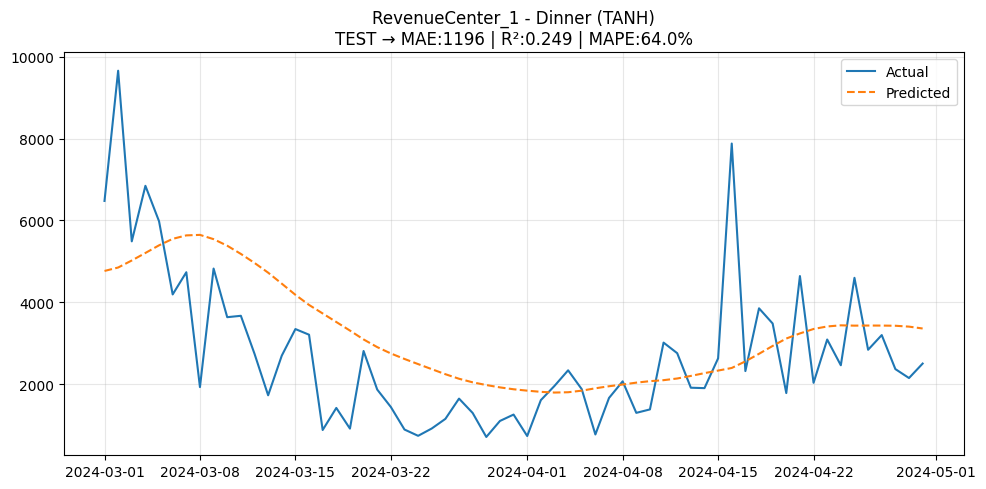

Saved: /content/RevenueCenter_1

ALL CENTERS COMPLETED — TANH MODEL


In [7]:
for file in files:

    center_name = os.path.basename(file).replace(".xlsx", "")
    print("\nProcessing:", center_name)

    center_path = os.path.join(output_folder, center_name)
    os.makedirs(center_path, exist_ok=True)

    df = pd.read_excel(file)
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date").reset_index(drop=True)

    split_date = df["Date"].max() - pd.DateOffset(months=2)
    meals = ["BreakFast", "Lunch", "Dinner"]

    for meal in meals:

        temp_df = df[["Date", meal]].copy()
        temp_df.rename(columns={meal: "y"}, inplace=True)

        train_df = temp_df[temp_df["Date"] <= split_date]
        test_df  = temp_df[temp_df["Date"] > split_date]

        if train_df["y"].nunique() <= 1:
            print(f"Skipping {center_name} - {meal} (constant values)")
            continue

        scaler = MinMaxScaler()
        train_scaled = scaler.fit_transform(train_df[["y"]])
        test_scaled  = scaler.transform(test_df[["y"]])

        WINDOW = 30
        X_train, y_train = create_sequences(train_scaled, WINDOW)
        combined = np.vstack([train_scaled[-WINDOW:], test_scaled])
        X_test, y_test = create_sequences(combined, WINDOW)

        X_train = X_train.reshape(-1, WINDOW, 1)
        X_test  = X_test.reshape(-1, WINDOW, 1)

        # =========================
        # MODEL — TANH
        # =========================
        model = Sequential([

            LSTM(
                256,
                activation="tanh",
                return_sequences=True,
                input_shape=(WINDOW, 1)
            ),

            LSTM(
                128,
                activation="tanh",
                return_sequences=True
            ),

            LSTM(
                64,
                activation="tanh",
                return_sequences=False
            ),

            Dense(1)
        ])

        model.compile(optimizer="adam", loss="mse")

        early_stop = EarlyStopping(
            monitor="val_loss",
            patience=15,
            restore_best_weights=True
        )

        history = model.fit(
            X_train, y_train,
            epochs=100,
            batch_size=16,
            validation_split=0.1,
            callbacks=[early_stop],
            verbose=1
        )

        # =========================
        # LOSS PLOT
        # =========================
        plt.figure(figsize=(8,5))
        plt.plot(history.history["loss"], label="Train Loss")
        plt.plot(history.history["val_loss"], label="Val Loss")
        plt.title(f"{center_name} - {meal} (TANH)")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig(os.path.join(center_path, f"{meal}_loss_tanh.png"), dpi=300)
        plt.show()
        plt.close()

        # =========================
        # PREDICTIONS
        # =========================
        y_train_pred = scaler.inverse_transform(model.predict(X_train))
        y_test_pred  = scaler.inverse_transform(model.predict(X_test))
        y_train_true = scaler.inverse_transform(y_train.reshape(-1,1))
        y_test_true  = scaler.inverse_transform(y_test.reshape(-1,1))

        train_mae  = mean_absolute_error(y_train_true, y_train_pred)
        train_r2   = r2_score(y_train_true, y_train_pred)
        train_mape = mape(y_train_true, y_train_pred)

        test_mae  = mean_absolute_error(y_test_true, y_test_pred)
        test_r2   = r2_score(y_test_true, y_test_pred)
        test_mape = mape(y_test_true, y_test_pred)

        plt.figure(figsize=(10,5))
        plt.plot(test_df["Date"], y_test_true, label="Actual")
        plt.plot(test_df["Date"], y_test_pred, "--", label="Predicted")
        plt.title(
            f"{center_name} - {meal} (TANH)\n"
            f"TEST → MAE:{test_mae:.0f} | R²:{test_r2:.3f} | MAPE:{test_mape:.1f}%"
        )
        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig(os.path.join(center_path, f"{meal}_pred_tanh.png"), dpi=300)
        plt.show()
        plt.close()

    print("Saved:", center_path)

print("\nALL CENTERS COMPLETED — TANH MODEL")

In [ ]:
y_min = y_train.min()
y_max = y_train.max()

print("Target range:", y_min, "to", y_max)
print("Range width:", y_max - y_min)

Target range: 0.0 to 37870.0
Range width: 37870.0
